# Regularization

Regularization is a technique used to reduce overfitting in machine
learning models.

It works by adding a penalty to large model coefficients.

Without regularization:

Model tries to minimize prediction error.

With regularization:

Model tries to minimize:

Prediction Error + Regularization Penalty

The main regularization techniques for linear regression are:

1. Ridge Regression
2. Lasso Regression
3. Elastic Net Regression

## Why Do We Need Regularization?

A model can become too complex and start learning noise from the
training data.

This is called overfitting.

Overfitting:

Training Performance → Very High
Testing Performance  → Much Lower

Regularization controls the size of model coefficients and can help
the model generalize better to unseen data.

## Regularization Intuition

Suppose a model has very large coefficients:

y = 5 + 100x1 + 250x2 - 180x3

Large coefficients can indicate that the model is becoming too
sensitive to the input features.

Regularization adds a penalty for large coefficients.

The model therefore prefers simpler solutions when possible.

## Mathematical Idea

Ordinary Linear Regression minimizes:

Σ(y - ŷ)²

Regularized regression adds an additional penalty.

Ridge:

Σ(y - ŷ)² + αΣβ²

Lasso:

Σ(y - ŷ)² + αΣ|β|

Elastic Net combines both penalties.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

We will predict:

Target:
- tip

Features:
- total_bill
- size

We will use multiple numerical features so that regularization can
control multiple model coefficients.

In [6]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (195, 2)
Testing: (49, 2)


## Feature Scaling

Regularization is affected by the magnitude of feature values.

Therefore, scaling is generally important when using Ridge, Lasso,
and Elastic Net.

We will use StandardScaler:

z = (x - mean) / standard deviation

The scaling will be placed inside a Pipeline to avoid data leakage.

In [8]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


# Ridge Regression

Ridge Regression uses L2 regularization.

The penalty is:

αΣβ²

The squared coefficients are added to the loss function.

Ridge tends to shrink coefficients toward zero but usually does not
make them exactly zero.

Important parameter:

alpha

A larger alpha means stronger regularization.

In [9]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [10]:
ridge_pred = ridge_pipeline.predict(
    X_test
)

ridge_pred[:10]

array([2.89875017, 1.90069296, 3.85917377, 3.98020515, 2.28275468,
       2.72442887, 3.67732512, 2.23578728, 2.4435277 , 2.49772085])

# Lasso Regression

Lasso Regression uses L1 regularization.

The penalty is:

αΣ|β|

Lasso can shrink some coefficients exactly to zero.

Therefore, Lasso can also perform feature selection.

Important parameter:

alpha

A larger alpha means stronger regularization.

In [11]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])

lasso_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [12]:
lasso_pred = lasso_pipeline.predict(
    X_test
)

lasso_pred[:10]

array([2.94143845, 2.01785852, 3.73066878, 3.84266852, 2.37140993,
       2.78012539, 3.66191437, 2.32794735, 2.5201857 , 2.57033484])

# Elastic Net Regression

Elastic Net combines:

- L1 regularization
- L2 regularization

Therefore, it combines ideas from Lasso and Ridge.

Elastic Net is useful when we have many features and some of them may
be correlated.

Important parameters:

alpha
l1_ratio

In [13]:
elastic_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        ElasticNet(
            alpha=0.1,
            l1_ratio=0.5
        )
    )
])

elastic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [14]:
elastic_pred = elastic_pipeline.predict(
    X_test
)

In [15]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(name)
    print("-" * 30)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print()

In [16]:
linear_pred = linear_pipeline.predict(
    X_test
)

evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_pred
)

evaluate_model(
    "Lasso Regression",
    y_test,
    lasso_pred
)

evaluate_model(
    "Elastic Net",
    y_test,
    elastic_pred
)

Linear Regression
------------------------------
MAE : 0.6639235737596481
MSE : 0.6485996190543514
RMSE: 0.8053568271607011
R²  : 0.4811084097989493

Ridge Regression
------------------------------
MAE : 0.6641807539013324
MSE : 0.6483857677877597
RMSE: 0.8052240481926504
R²  : 0.48127949473413634

Lasso Regression
------------------------------
MAE : 0.6548094795721159
MSE : 0.6122095126615545
RMSE: 0.7824381845625599
R²  : 0.5102211622875712

Elastic Net
------------------------------
MAE : 0.6609643338709014
MSE : 0.62963422377784
RMSE: 0.7934949425030005
R²  : 0.49628107383499753



In [17]:
linear_model = linear_pipeline.named_steps["model"]
ridge_model = ridge_pipeline.named_steps["model"]
lasso_model = lasso_pipeline.named_steps["model"]
elastic_model = elastic_pipeline.named_steps["model"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "ElasticNet": elastic_model.coef_
})

coefficients

,Feature,Linear,Ridge,Lasso,ElasticNet
0,total_bill,0.795027,0.790135,0.731173,0.719747
1,size,0.248660,0.250146,0.184788,0.229765


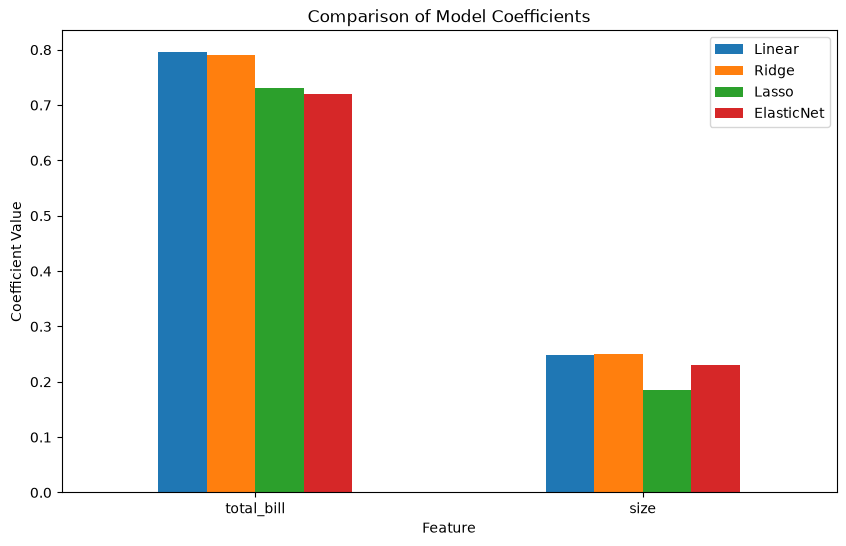

In [18]:
coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Model Coefficients")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=0)

plt.show()

In [19]:
alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

ridge_results = []

for alpha in alphas:

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    train_r2 = pipeline.score(
        X_train,
        y_train
    )

    test_r2 = pipeline.score(
        X_test,
        y_test
    )

    ridge_results.append({
        "Alpha": alpha,
        "Train_R2": train_r2,
        "Test_R2": test_r2
    })

ridge_results = pd.DataFrame(
    ridge_results
)

ridge_results

,Alpha,Train_R2,Test_R2
0,0.001,0.451642,0.481109
1,0.010,0.451642,0.481110
2,0.100,0.451642,0.481126
3,1.000,0.451633,0.481279
4,10.000,0.450864,0.482197
5,100.000,0.416740,0.457322


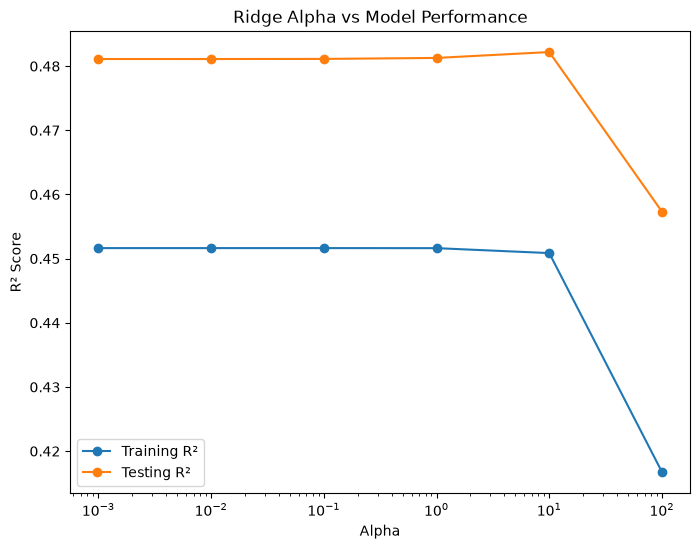

In [20]:
plt.figure(figsize=(8, 6))

plt.semilogx(
    ridge_results["Alpha"],
    ridge_results["Train_R2"],
    marker="o",
    label="Training R²"
)

plt.semilogx(
    ridge_results["Alpha"],
    ridge_results["Test_R2"],
    marker="o",
    label="Testing R²"
)

plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Ridge Alpha vs Model Performance")

plt.legend()

plt.show()

## Ridge vs Lasso vs Elastic Net

### Ridge

Uses L2 regularization.

Penalty:

Σβ²

- Shrinks coefficients
- Usually keeps all features
- Useful when features are correlated


### Lasso

Uses L1 regularization.

Penalty:

Σ|β|

- Shrinks coefficients
- Can make coefficients exactly zero
- Can perform feature selection


### Elastic Net

Uses both L1 and L2 regularization.

- Combines Ridge and Lasso
- Useful with many features
- Useful when features are correlated